In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df=pd.read_csv('/kaggle/input/weather-prediction/seattle-weather.csv')
print(df)

            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


In [3]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


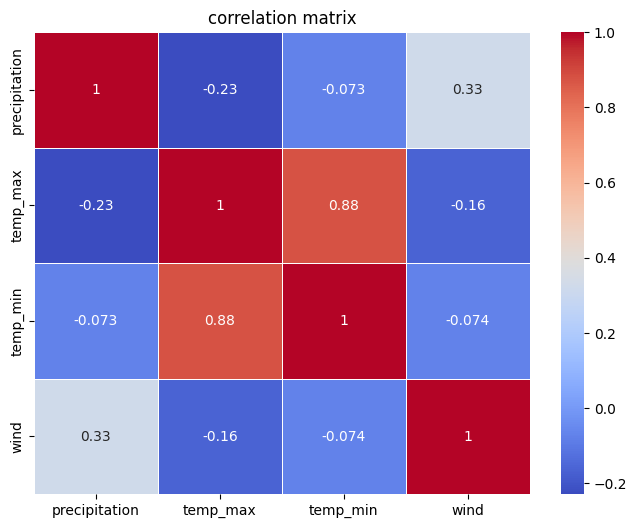

In [6]:
#correlation
corr=df[['precipitation','temp_max','temp_min','wind']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,cmap='coolwarm',annot=True,linewidth=0.5)
plt.title("correlation matrix")
plt.show()


In [7]:
# 2. Convert the 'date' column to datetime and extract the hour (if needed)
df['date'] = pd.to_datetime(df['date'])
df['rain']=(df["weather"]=='rain').astype(int)
df=df.drop(columns=['weather'])




In [8]:
#define features and target
X=df[['precipitation','temp_max','temp_min','wind']]
y=df['rain']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
classifier = LogisticRegression(max_iter=1000)  
classifier.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [11]:
y_pred = classifier.predict(X_test)


In [12]:
# 9. Evaluate the Classifier
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8600682593856656


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[157  16]
 [ 25  95]]


In [14]:
#classification report 

print("classification report:\n",classification_report(y_test,y_pred))

classification report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       173
           1       0.86      0.79      0.82       120

    accuracy                           0.86       293
   macro avg       0.86      0.85      0.85       293
weighted avg       0.86      0.86      0.86       293



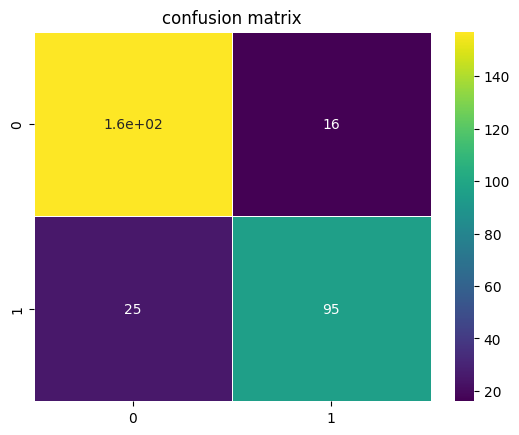

In [15]:
sns.heatmap(cm,annot=True,linewidth=0.5,cmap='viridis')
plt.title("confusion matrix")
plt.show()

# using random forest

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   rain           1461 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 68.6 KB


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

In [18]:
classifier = KNeighborsClassifier(n_neighbors=39, p=2,metric='euclidean')

In [19]:
classifier.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=39)

In [20]:
y_pred=classifier.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0])

In [21]:
#confusion matrix
cm_rf=confusion_matrix(y_test,y_pred)
cm_rf

array([[153,  17],
       [ 31,  92]])

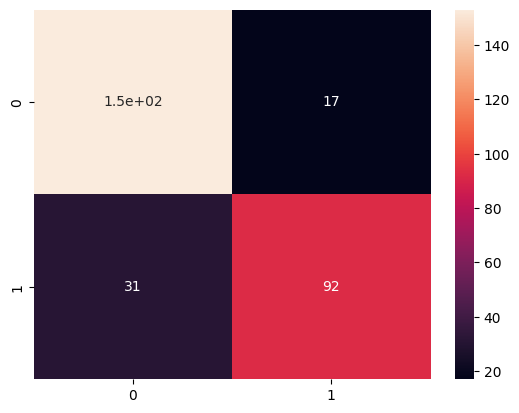

In [22]:
sns.heatmap(cm_rf,annot=True,color='gray')
plt.show()

In [23]:
print(f"classification report\n {classification_report(y_test,y_pred)}")

classification report
               precision    recall  f1-score   support

           0       0.83      0.90      0.86       170
           1       0.84      0.75      0.79       123

    accuracy                           0.84       293
   macro avg       0.84      0.82      0.83       293
weighted avg       0.84      0.84      0.83       293



In [24]:
print(df.columns.to_list())

['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'rain']


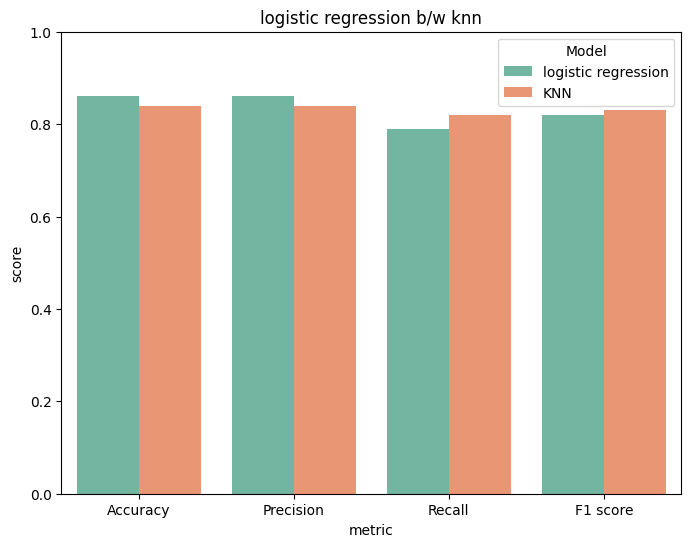

In [28]:
import pandas as pd

Metric={
    'Metric':['Accuracy','Precision','Recall','F1 score'],
    'logistic regression':[0.86,0.86,0.79,0.82],
    'KNN':[0.84,0.84,0.82,0.83]
}

df=pd.DataFrame(Metric)

plt.figure(figsize=(8,6))
df_melted=df.melt(id_vars='Metric',var_name='Model',value_name='score')

sns.barplot(x='Metric',y='score',hue='Model',data=df_melted,palette='Set2')




plt.ylim(0,1)
plt.title("logistic regression b/w knn")
plt.ylabel('score')
plt.xlabel('metric')


# legend
plt.legend(title='Model')

plt.show()
    
